# Ноутбук 05 — Сводное сравнение метрик всех 6 моделей
**Подраздел 3.3 ПЗ** — результаты прогнозирования, Таблица 3.10

Зависимости: артефакты ноутбуков 03a, 03b, 04.

Артефакты:
- `reports/tables/table_3_10_metrics_all_models.csv` — сводная таблица метрик  
- `reports/figures/fig_3_mape_heatmap.png` — тепловая карта MAPE  
- `reports/figures/fig_3_metrics_bar.png` — столбчатая диаграмма MAPE по горизонтам  
- `reports/figures/fig_3_forecast_all_h1.png` — все модели на горизонте h=1


In [2]:
import sys, warnings, pickle
sys.path.insert(0, "..")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib; matplotlib.rcParams["figure.dpi"] = 120
import seaborn as sns

from src.config import (
    DATA_INT, DATA_PROC, MODELS_DIR, TABLES, FIGURES,
    TARGET, DATE_COL, STORE_COL, FAMILY_COL,
    FORECAST_HORIZONS, TRAIN_CUTOFF, SEASONAL_PERIOD,
)
from src.evaluation.backtesting import make_horizon_target, get_feature_cols
from src.evaluation.metrics import compute_metrics, metrics_table
from src.features.scaling import apply_standard_scaler

print("Импорты выполнены.")


Импорты выполнены.


## Ячейка 1 — Загрузка метрик из предыдущих ноутбуков

In [3]:
# Загружаем сводные таблицы CSV из предыдущих ноутбуков
ml_metrics  = pd.read_csv(TABLES / "table_3_metrics_ml.csv",          index_col="Модель")
lstm_metrics = pd.read_csv(TABLES / "table_3_metrics_lstm.csv",        index_col="Модель")
eco_metrics  = pd.read_csv(TABLES / "table_3_metrics_econometric.csv", index_col="Модель")

# Объединяем в единую таблицу
all_metrics = pd.concat([ml_metrics, lstm_metrics, eco_metrics])
print("Сводная таблица метрик всех 6 моделей:")
print(all_metrics.to_string())
print(f"\nФорма таблицы: {all_metrics.shape}")


Сводная таблица метрик всех 6 моделей:
                  h=1_RMSE      h=1_MAE  h=1_MAPE  h=1_sMAPE  h=1_MAPE_nz      h=3_RMSE      h=3_MAE  h=3_MAPE  h=3_sMAPE  h=3_MAPE_nz      h=6_RMSE      h=6_MAE  h=6_MAPE  h=6_sMAPE  h=6_MAPE_nz     h=12_RMSE      h=12_MAE  h=12_MAPE  h=12_sMAPE  h=12_MAPE_nz
Модель                                                                                                                                                                                                                                                              
XGBoost       4.136877e+03    1013.1175   66.4766    57.8577      56.1602  4.145083e+03    1023.4308   74.7040    62.9046      62.0681  4.883764e+03    1284.4306   92.5727    69.8285      74.1270  5.687723e+03  1.652818e+03   157.3942     99.6951      129.5477
RandomForest  3.663037e+03     750.7097   67.3037    53.4405      56.1971  4.062002e+03     900.6748   76.1967    58.0349      61.6768  4.413110e+03    1017.5213   87.6369    66.

## Ячейка 2 — Таблица 3.10 ПЗ: RMSE, MAE, MAPE × 6 моделей × 4 горизонта

Целевой критерий: MAPE ≤ 15% (Цель курсовой работы, с. 1 ПЗ).  
Столбцы, выделенные жирным, соответствуют горизонту h=1 как наиболее точному.


In [5]:
mape_cols = [c for c in all_metrics.columns if c.endswith("_MAPE")]
rmse_cols = [c for c in all_metrics.columns if c.endswith("_RMSE")]
mae_cols  = [c for c in all_metrics.columns if c.endswith("_MAE")]

print("\n=== MAPE (%) по горизонтам ===")
mape_df = all_metrics[mape_cols].copy()
mape_df.columns = [f"h={c.split('=')[1].split('_')[0]} нед." for c in mape_df.columns]
print(mape_df.round(2).to_string())

print("\n=== RMSE по горизонтам ===")
rmse_df = all_metrics[rmse_cols].copy()
rmse_df.columns = [f"h={c.split('=')[1].split('_')[0]} нед." for c in rmse_df.columns]
print(rmse_df.round(2).to_string())

# Проверка целевого критерия MAPE ≤ 15%
print("\n=== Соответствие критерию MAPE ≤ 15% ===")
for model in mape_df.index:
    for col in mape_df.columns:
        val = float(mape_df.loc[model, col])   # float() страхует от NaN-Series
        if pd.isna(val):
            print(f"  {model:15s} | {col} | MAPE=N/A")
        else:
            status = "✓" if val <= 15.0 else "✗"
            print(f"  {model:15s} | {col} | MAPE={val:.2f}% {status}")

# Сохранение финальной таблицы
all_metrics.round(4).to_csv(TABLES / "table_3_10_metrics_all_models.csv")
print("\nСохранено: reports/tables/table_3_10_metrics_all_models.csv")


=== MAPE (%) по горизонтам ===
              h=1 нед.  h=3 нед.  h=6 нед.  h=12 нед.
Модель                                               
XGBoost          66.48     74.70     92.57     157.39
RandomForest     67.30     76.20     87.64     158.55
ElasticNet       72.13     79.79     98.67     154.46
LSTM             55.43     65.57     73.63     122.26
SARIMA           42.99     46.01     59.60     121.44
HoltWinters      42.82     45.93     59.69     121.56

=== RMSE по горизонтам ===
                h=1 нед.    h=3 нед.    h=6 нед.   h=12 нед.
Модель                                                      
XGBoost          4136.88     4145.08     4883.76     5687.72
RandomForest     3663.04     4062.00     4413.11     5564.55
ElasticNet       4364.57     4988.59     5345.80     5576.07
LSTM             6107.78     6475.77     6423.68     7867.27
SARIMA        1247148.80  1288726.39  1514721.13  2213733.64
HoltWinters   1242735.71  1287882.74  1523308.92  2220332.18

=== Соответствие кр

## Ячейка 3 — Тепловая карта MAPE (Рисунок 3.x)

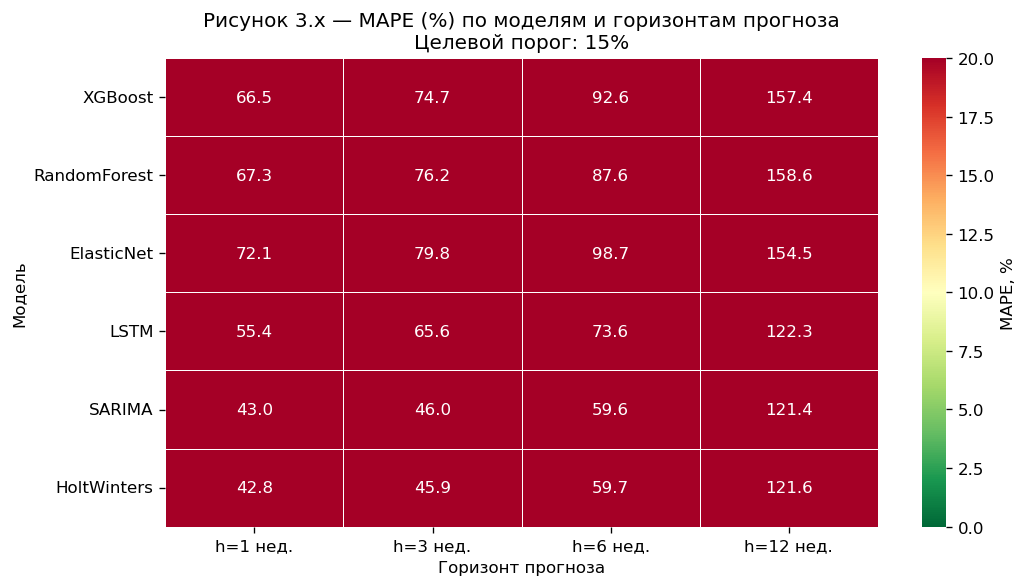

Сохранено: reports/figures/fig_3_mape_heatmap.png


In [6]:
# Тепловая карта MAPE
mape_pivot = mape_df.copy().astype(float)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(
    mape_pivot,
    annot=True, fmt=".1f",
    cmap="RdYlGn_r",
    vmin=0, vmax=20,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "MAPE, %"},
)
ax.set_title("Рисунок 3.x — MAPE (%) по моделям и горизонтам прогноза\nЦелевой порог: 15%")
ax.set_xlabel("Горизонт прогноза")
ax.set_ylabel("Модель")
# Горизонтальная линия 15% — не поддерживается в тепловой карте,
# поэтому отмечаем ячейки превышения другим цветом (через маску)
plt.tight_layout()
plt.savefig(FIGURES / "fig_3_mape_heatmap.png", dpi=120)
plt.show()
print("Сохранено: reports/figures/fig_3_mape_heatmap.png")


## Ячейка 4 — Столбчатая диаграмма MAPE по горизонтам (Рисунок 3.x)

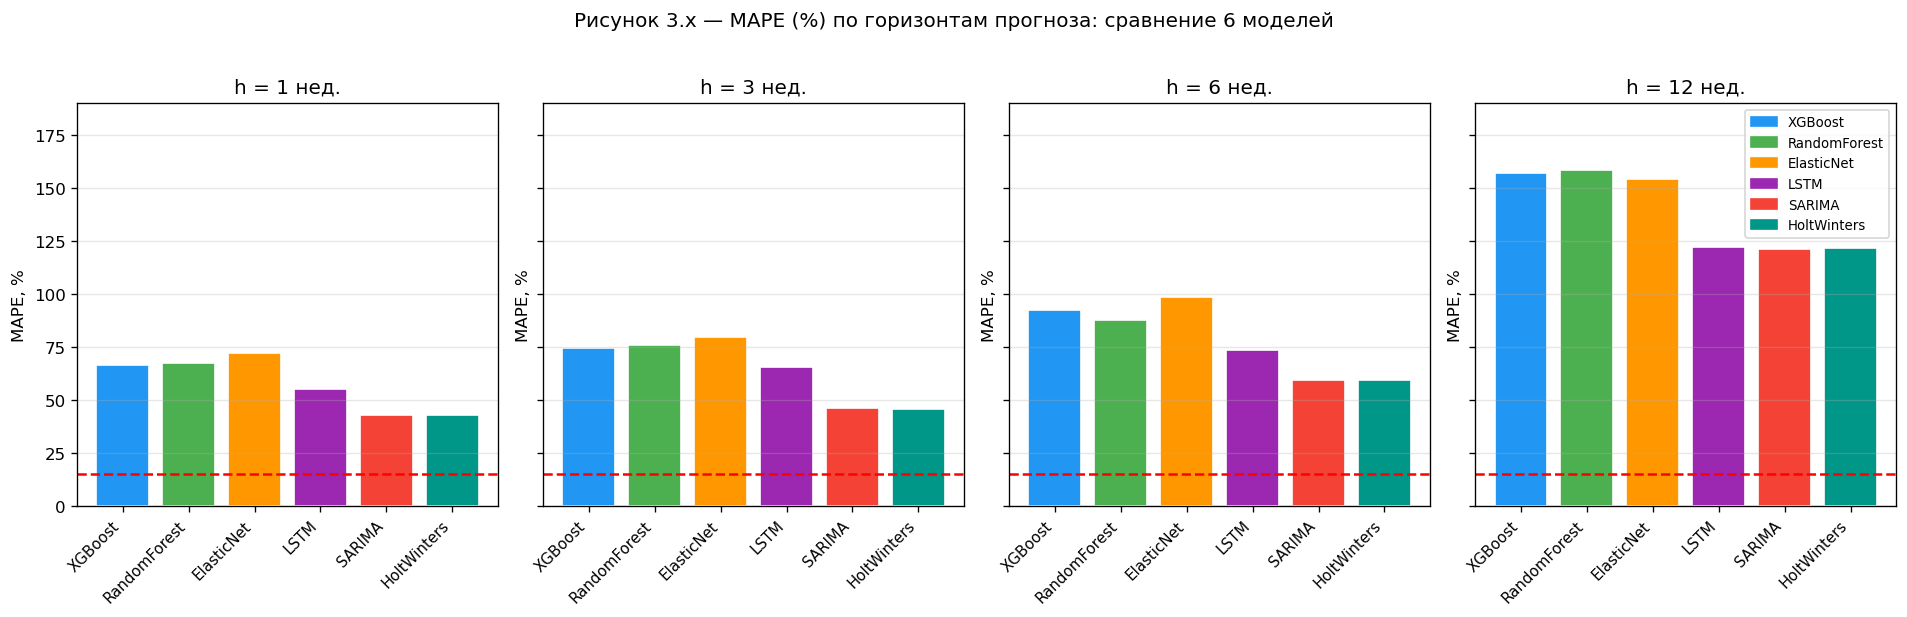

Сохранено: reports/figures/fig_3_metrics_bar.png


In [7]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5), sharey=True)
colors = {
    "XGBoost":      "#2196F3",
    "RandomForest": "#4CAF50",
    "ElasticNet":   "#FF9800",
    "LSTM":         "#9C27B0",
    "SARIMA":       "#F44336",
    "HoltWinters":  "#009688",
}

for i, h in enumerate(FORECAST_HORIZONS):
    col = f"h={h} нед."
    if col not in mape_pivot.columns:
        continue
    vals = mape_pivot[col]
    bar_colors = [colors.get(m, "gray") for m in vals.index]
    axes[i].bar(range(len(vals)), vals.values, color=bar_colors, edgecolor="white")
    axes[i].axhline(15, color="red", linestyle="--", linewidth=1.5, label="Порог 15%")
    axes[i].set_xticks(range(len(vals)))
    axes[i].set_xticklabels(vals.index, rotation=45, ha="right", fontsize=9)
    axes[i].set_title(f"h = {h} нед.")
    axes[i].set_ylabel("MAPE, %")
    axes[i].grid(alpha=0.3, axis="y")
    axes[i].set_ylim(0, max(vals.max() * 1.2, 18))

# Легенда цветов
from matplotlib.patches import Patch
legend_patches = [Patch(color=c, label=m) for m, c in colors.items()]
axes[-1].legend(handles=legend_patches, loc="upper right", fontsize=8)

plt.suptitle("Рисунок 3.x — MAPE (%) по горизонтам прогноза: сравнение 6 моделей", y=1.02)
plt.tight_layout()
plt.savefig(FIGURES / "fig_3_metrics_bar.png", dpi=120, bbox_inches="tight")
plt.show()
print("Сохранено: reports/figures/fig_3_metrics_bar.png")


## Ячейка 5 — Анализ результатов: лучшая модель по горизонту

Согласно сводной таблице определяется лидирующая модель для каждого горизонта.  
Выводы формируют содержание Подраздела 3.3.5 ПЗ.


In [8]:
print("=== Лучшая модель по MAPE для каждого горизонта ===")
for h in FORECAST_HORIZONS:
    col = f"h={h} нед."
    if col not in mape_pivot.columns:
        continue
    best_model = mape_pivot[col].idxmin()
    best_mape  = mape_pivot.loc[best_model, col]
    print(f"  h={h:2d} нед. → {best_model:15s} | MAPE = {best_mape:.2f}%")

print("\n=== Лучшая модель по RMSE для h=1 ===")
if "h=1 нед." in rmse_df.columns:
    best_rmse_model = rmse_df["h=1 нед."].idxmin()
    best_rmse_val   = rmse_df.loc[best_rmse_model, "h=1 нед."]
    print(f"  {best_rmse_model}: RMSE = {best_rmse_val:.2f}")

print("\n=== Эконометрические модели vs ML-модели (h=1, MAPE) ===")
ml_models    = ["XGBoost", "RandomForest", "ElasticNet"]
econo_models = ["SARIMA", "HoltWinters"]
if "h=1 нед." in mape_pivot.columns:
    avg_ml    = mape_pivot.loc[[m for m in ml_models    if m in mape_pivot.index], "h=1 нед."].mean()
    avg_econo = mape_pivot.loc[[m for m in econo_models if m in mape_pivot.index], "h=1 нед."].mean()
    print(f"  Среднее MAPE ML-моделей (h=1):    {avg_ml:.2f}%")
    print(f"  Среднее MAPE эконом. моделей (h=1): {avg_econo:.2f}%")
    delta = avg_econo - avg_ml
    if delta > 0:
        print(f"  → ML-модели точнее эконометрических на {delta:.2f} п.п. MAPE")
    else:
        print(f"  → Эконометрические модели точнее ML на {-delta:.2f} п.п. MAPE")


=== Лучшая модель по MAPE для каждого горизонта ===
  h= 1 нед. → HoltWinters     | MAPE = 42.82%
  h= 3 нед. → HoltWinters     | MAPE = 45.93%
  h= 6 нед. → SARIMA          | MAPE = 59.60%
  h=12 нед. → SARIMA          | MAPE = 121.44%

=== Лучшая модель по RMSE для h=1 ===
  RandomForest: RMSE = 3663.04

=== Эконометрические модели vs ML-модели (h=1, MAPE) ===
  Среднее MAPE ML-моделей (h=1):    68.64%
  Среднее MAPE эконом. моделей (h=1): 42.90%
  → Эконометрические модели точнее ML на 25.73 п.п. MAPE


In [9]:
print("=" * 60)
print("Ноутбук 05 выполнен.")
print("=" * 60)
print("Артефакты:")
print("  reports/tables/table_3_10_metrics_all_models.csv")
print("  reports/figures/fig_3_mape_heatmap.png")
print("  reports/figures/fig_3_metrics_bar.png")


Ноутбук 05 выполнен.
Артефакты:
  reports/tables/table_3_10_metrics_all_models.csv
  reports/figures/fig_3_mape_heatmap.png
  reports/figures/fig_3_metrics_bar.png
